# Análisis Exploratorio de Datos (EDA) - Sesgo en COMPAS

Este notebook realiza un análisis exploratorio de los datos limpios de COMPAS, focalizándose en el desbalanceo y los sesgos inherentes entre los grupos raciales (African-American vs Caucasian).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

sns.set_theme(style="whitegrid")

In [2]:
data_path = os.path.join('..', 'data', 'processed', 'compas_cleaned.csv')
df = pd.read_csv(data_path)
df.head()

,sex,age,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,c_charge_desc,score_text,decile_score,two_year_recid
0,Male,34,25 - 45,African-American,0,0,0,0,F,Felony Battery w/Prior Convict,Low,3,1
1,Male,24,Less than 25,African-American,0,0,1,4,F,Possession of Cocaine,Low,4,1
2,Male,41,25 - 45,Caucasian,0,0,0,14,F,Possession Burglary Tools,Medium,6,1
3,Female,39,25 - 45,Caucasian,0,0,0,0,M,Battery,Low,1,0
4,Male,27,25 - 45,Caucasian,0,0,0,0,F,"Poss 3,4 MDMA (Ecstasy)",Low,4,0


## 1. Distribución de Raza en el Dataset

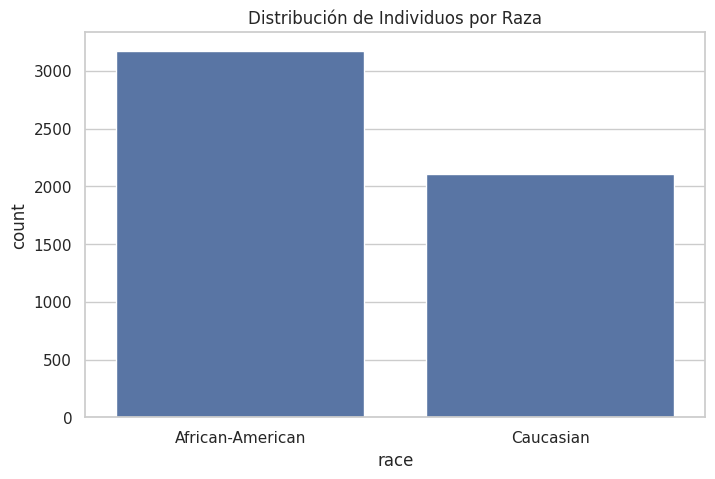

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='race')
plt.title('Distribución de Individuos por Raza')
plt.show()

## 2. Reincidencia por Raza
Analizamos la tasa de reincidencia real (`two_year_recid`) comparando ambos grupos.

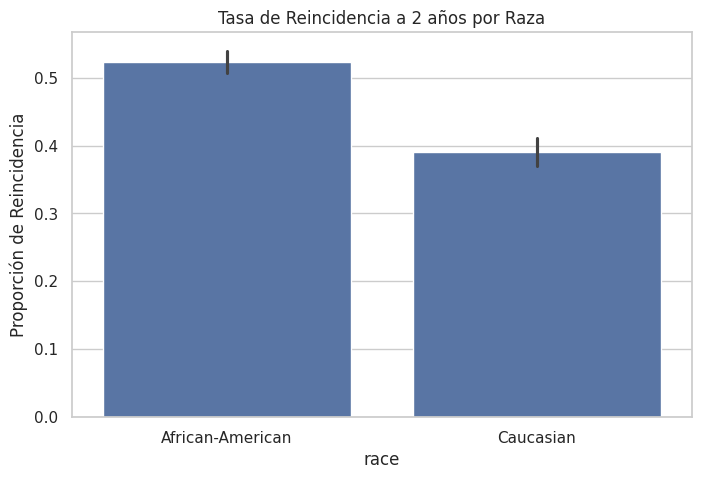

In [4]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='race', y='two_year_recid')
plt.title('Tasa de Reincidencia a 2 años por Raza')
plt.ylabel('Proporción de Reincidencia')
plt.show()

## 3. Distribución de Puntuaciones COMPAS (Decile Score) por Raza

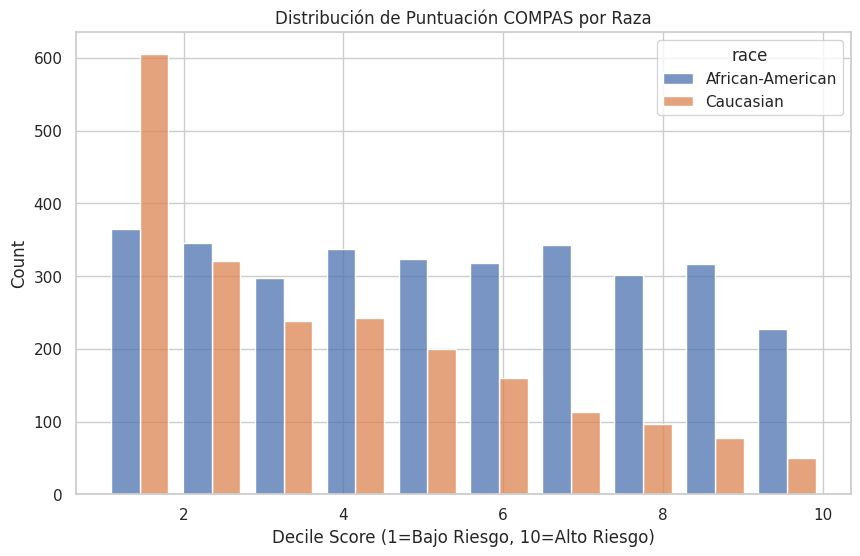

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='decile_score', hue='race', multiple="dodge", shrink=.8, bins=10)
plt.title('Distribución de Puntuación COMPAS por Raza')
plt.xlabel('Decile Score (1=Bajo Riesgo, 10=Alto Riesgo)')
plt.show()

### Conclusión del EDA
Como demostró ProPublica, la distribución de las puntuaciones de riesgo está sesgada: los acusados afroamericanos tienen una probabilidad mucho mayor de recibir puntuaciones de riesgo alto, mientras que los acusados caucásicos tienen una probabilidad mayor de recibir puntuaciones bajas.